# Script to load a netcdf file, make a map in both xarray, and a prettier map with more user-defined changes using Matplotlib

## define paths to data, for saving figures, etc

In [1]:

#era5 data path
DATAPATH_era5 = '/hpc/home/'

filename = 'eraw5_t2m_1970.nc'


## import packages in conda

In [2]:
#import utils #utils file with functions

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import xarray as xr


import matplotlib.pyplot as plt
import cartopy.crs as ccrs


## load era5 model data into xarray as a dataset (ds)

In [3]:
ds = xr.open_dataset(DATAPATH_era5 + filename)

FileNotFoundError: [Errno 2] No such file or directory: '/hpc/home/eraw5_t2m_1970.nc'

In [5]:
!pip3 install basemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.8/581.8 kB 11.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 38.3 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: pyshp
    Found existing installation: pyshp 3.0.2.post1
    Uninstalling pyshp-3.0.2.post1:
      Successfully uninstalled pyshp-3.0.2.post1 0/3 [pyshp]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [basemap]m2/3 [basemap]data]


## list file attributes in this newly defined variable/dataset
### it's a good idea to know what the variable name is, what the lat/lon dimensions and names are, etc

In [ ]:
ds 

<xarray.Dataset>
Dimensions:    (bnds: 2, lat: 64, lon: 128, time: 1032)
Coordinates:
  * time       (time) object 2015-01-16 12:00:00 ... 2100-12-16 12:00:00
  * lat        (lat) float64 -87.86 -85.1 -82.31 -79.53 ... 82.31 85.1 87.86
  * lon        (lon) float64 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object ...
    lat_bnds   (lat, bnds) float64 ...
    lon_bnds   (lon, bnds) float64 ...
    drybc      (time, lat, lon) float32 ...
Attributes:
    CCCma_model_hash:            1f91f92cb6d607391f44831504025d32fc44faa1
    CCCma_parent_runid:          rc3.1-his01
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 rc3.1-s2601
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   2015:01:01:00
    YMDH_branch_time_in_parent:  2015:01:01:00
    activity_id:                 ScenarioMIP
    branch_method:               Spin-up documentation
    branch_time_in_child:        60225.0
    branch_time_in_parent:       60225.0
    contact:                     ec.cccma.info-info.ccmac.ec@canada.ca
    creation_date:               2019-05-01T22:25:51Z
    data_specs_version:          01.00.29
    experiment:                  update of RCP2.6 based on SSP1
    experiment_id:               ssp126
    external_variables:          areacella
    forcing_index:               1
    frequency:                   mon
    further_info_url:            https://furtherinfo.es-doc.org/CMIP6.CCCma.C...
    grid:                        T63L49 native atmosphere, T63 Linear Gaussia...
    grid_label:                  gn
    history:                     2019-05-01T22:25:51Z ;rewrote data to be con...
    initialization_index:        1
    institution:                 Canadian Centre for Climate Modelling and An...
    institution_id:              CCCma
    mip_era:                     CMIP6
    nominal_resolution:          500 km
    parent_activity_id:          CMIP
    parent_experiment_id:        historical
    parent_mip_era:              CMIP6
    parent_source_id:            CanESM5
    parent_time_units:           days since 1850-01-01 0:0:0.0
    parent_variant_label:        r1i1p1f1
    physics_index:               1
    product:                     model-output
    realization_index:           1
    realm:                       aerosol
    references:                  Geophysical Model Development Special issue ...
    source:                      CanESM5 (2019): \naerosol: interactive\natmo...
    source_id:                   CanESM5
    source_type:                 AOGCM
    sub_experiment:              none
    sub_experiment_id:           none
    table_id:                    AERmon
    table_info:                  Creation Date:(20 February 2019) MD5:374fbe5...
    title:                       CanESM5 output prepared for CMIP6
    tracking_id:                 hdl:21.14100/cb3b672f-81e5-4c1a-83a1-5602bb7...
    variable_id:                 drybc
    variant_label:               r1i1p1f1
    version:                     v20190429
    license:                     CMIP6 model data produced by The Government ...
    cmor_version:                3.4.0

## use Xarray's internal plot function to plot a quick, ugly, simple global map of the variable 'drybc' for the first time step - note no coast lines, etc so hard to tell what you're looking at!

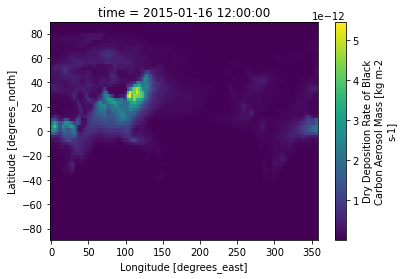

In [ ]:
ds['t2m'][0,:,:].plot()

## now make a 'pretty' map of the same data using matplotlib pyplot (imported as 'plt' above)
### also note here we use the package cartopy crs (ccrs) to hel with the map projection of gridded data onto the global map

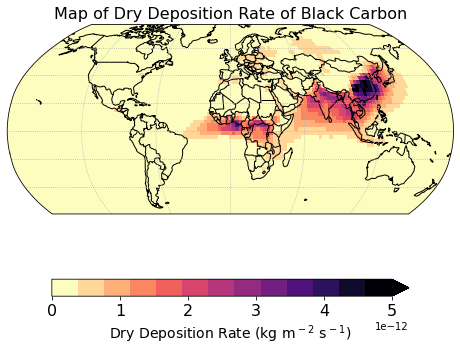

In [ ]:

#defie figure size (x,y)
fig = plt.figure(figsize=(8,8))
#define longitude, latitude extend of data (negative is degrees east, or degrees south of equator)
extent = [-179.999, 179.99, -60, 80]
#define fontsize
fsize = 16

#now start defining the plot parameters starting with the map projection, and central longitude on the map
ax = plt.subplot(1,1,1,projection = ccrs.Robinson(central_longitude=0))
ax.set_global()
ax.coastlines(resolution='110m', linewidth=1, color='black') #draw coastlines in black
ax.set_extent(extent)
ax.add_feature(cf.BORDERS,linewidth=1,color='black') #draw country borders in black
ax.gridlines(linestyle=':') #draw lat/lon grid lines
plotvalue = ds['t2m'][0,:,:] #define variable to be plotted - we are picking first time step 0
im = plt.pcolormesh(
            plotvalue.lon,
            plotvalue.lat,
            plotvalue,
            cmap=plt.cm.get_cmap('magma_r',13),
            vmin=0, vmax=330, #set color bar min and max
            transform=ccrs.PlateCarree())
plt.title('Map of air temperature',fontsize=fsize,ha='center')

#plot colorbar, define arrow ends of colorbar (max, min, both), size (shrink 0.8 will be 80% of plot size)
cbar1=plt.colorbar(im,extend='max',orientation='horizontal',shrink=0.8) 
cbar1.ax.tick_params(labelsize=fsize)
cbar1.set_label('Air temperature ($^o$C))',fontsize=fsize-2)

#save figure as a png file at 300dpi resolution, with a white background, to the specified directory
# fig.savefig('Test_Map.png',
#             dpi=300,bbox_inches='tight',facecolor='white')